# 🔬 NGHIÊN CỨU SÂU — Kiểm Tra Dữ Liệu & Phân Tích Sản Phẩm

File tạm thời để điều tra kỹ lưỡng 4 vấn đề:
1. **Sản phẩm Ma (Ghost Products)** — Phân phối giá, tứ phân vị, quyết định cắt  
2. **Biến phân loại** — Liệt kê giá trị khi unique < 10  
3. **Revenue Reconciliation** — Đối chiếu sales.csv vs payments + order_items  
4. **Phân tích Sản phẩm theo Thời gian** — Tồn kho, biến động, phân khúc, màu sắc

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

def find_project_root():
    candidates = [Path.cwd(), Path.cwd() / 'VinDatathon_the-4-Outliers', *Path.cwd().parents]
    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        has_clean = (candidate / 'data' / 'clean' / 'orders.parquet').exists()
        has_raw = (candidate / 'datathon-2026-round-1' / 'orders.csv').exists()
        if has_clean or has_raw:
            return candidate
    raise FileNotFoundError('Could not locate project root containing clean parquet or raw csv data')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from theme import apply_theme, style_ax, annotate_bar, add_insight, make_legend, get_palette, colors_for, COLORS, C, SEQ_BLUE, SEQ_AMBER, DIV, CLR_TITLE, CLR_MUTED, CLR_LABEL
apply_theme()

DATA = PROJECT_ROOT / 'data' / 'clean'
FEAT = PROJECT_ROOT / 'data' / 'features'
RAW = PROJECT_ROOT / 'datathon-2026-round-1'
CLEAN = DATA
table_sources = {}

def read_table(name, parse_dates=None):
    parquet_path = DATA / f'{name}.parquet'
    csv_path = RAW / f'{name}.csv'
    if parquet_path.exists():
        df = pd.read_parquet(parquet_path)
        source = 'parquet'
    elif csv_path.exists():
        df = pd.read_csv(csv_path, low_memory=False)
        source = 'csv'
    else:
        raise FileNotFoundError(f'Missing both {parquet_path.name} and {csv_path.name}')

    if name == 'sales' and 'date' in df.columns and 'Date' not in df.columns:
        df = df.rename(columns={'date': 'Date'})

    for col in parse_dates or []:
        if col in df.columns and not pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col] = pd.to_datetime(df[col], errors='coerce')

    table_sources[name] = source
    return df

products = read_table('products')
order_items = read_table('order_items')
orders = read_table('orders', parse_dates=['order_date'])
payments = read_table('payments')
returns = read_table('returns', parse_dates=['return_date'])
sales = read_table('sales', parse_dates=['Date'])
inventory = read_table('inventory')
shipments = read_table('shipments', parse_dates=['ship_date', 'delivery_date'])

dfs = {
    'products': products,
    'order_items': order_items,
    'orders': orders,
    'payments': payments,
    'returns': returns,
    'sales': sales,
    'inventory': inventory,
    'shipments': shipments,
}

print(f'Loaded all data from {PROJECT_ROOT}')
for k, v in dfs.items():
    print(f'  {k}: {v.shape} [{table_sources[k]}]')
# -- Load shared features (prefer parquet, fallback to None) --

def load_shared():
    """Load 3 shared feature tables from Phase 2 if available."""
    try:
        li = pd.read_parquet(FEAT / 'shared_line_items.parquet')
        sd = pd.read_parquet(FEAT / 'shared_daily.parquet')
        sc = pd.read_parquet(FEAT / 'shared_calendar.parquet')
        print('[OK] Loaded shared features from parquet')
        return li, sd, sc
    except Exception as e:
        print(f'[WARN] Shared features unavailable: {e}')
        print('[FALLBACK] Continue notebook with base tables only')
        return None, None, None

shared_line_items, shared_daily, shared_calendar = load_shared()


Vivid Slate theme applied.
Loaded all data from D:\B. COMPUTER SCIENCE PROJECTS\D. DATATHON\VinDatathon_the-4-Outliers
  products: (2412, 8) [parquet]
  order_items: (714669, 7) [parquet]
  orders: (646945, 8) [parquet]
  payments: (646945, 4) [parquet]
  returns: (39939, 7) [parquet]
  sales: (3833, 3) [parquet]
  inventory: (60247, 17) [parquet]
  shipments: (566067, 4) [parquet]
[OK] Loaded shared features from parquet


---
## 1. SẢN PHẨM MA (Ghost Products) — Phân phối giá & Tứ phân vị

Tổng SP: 2412 | Active: 1598 | Ghost: 814 (33.7%)
Ghost KHÔNG có trong Kho: 788

TỨ PHÂN VỊ GIÁ — GHOST vs ACTIVE

  Ghost (814 SP):
    Min (Q0):         9.06
    Q1 (25%):        26.99
    Median(50%):     37.21
    Q3 (75%):        60.90
    Max (Q4):    40,950.00
    Mean:         1,598.50
    IQR:             33.91

  Active (1598 SP):
    Min (Q0):       440.37
    Q1 (25%):     3,779.37
    Median(50%):  5,505.13
    Q3 (75%):     9,130.53
    Max (Q4):    40,950.00
    Mean:         6,624.33
    IQR:          5,351.16


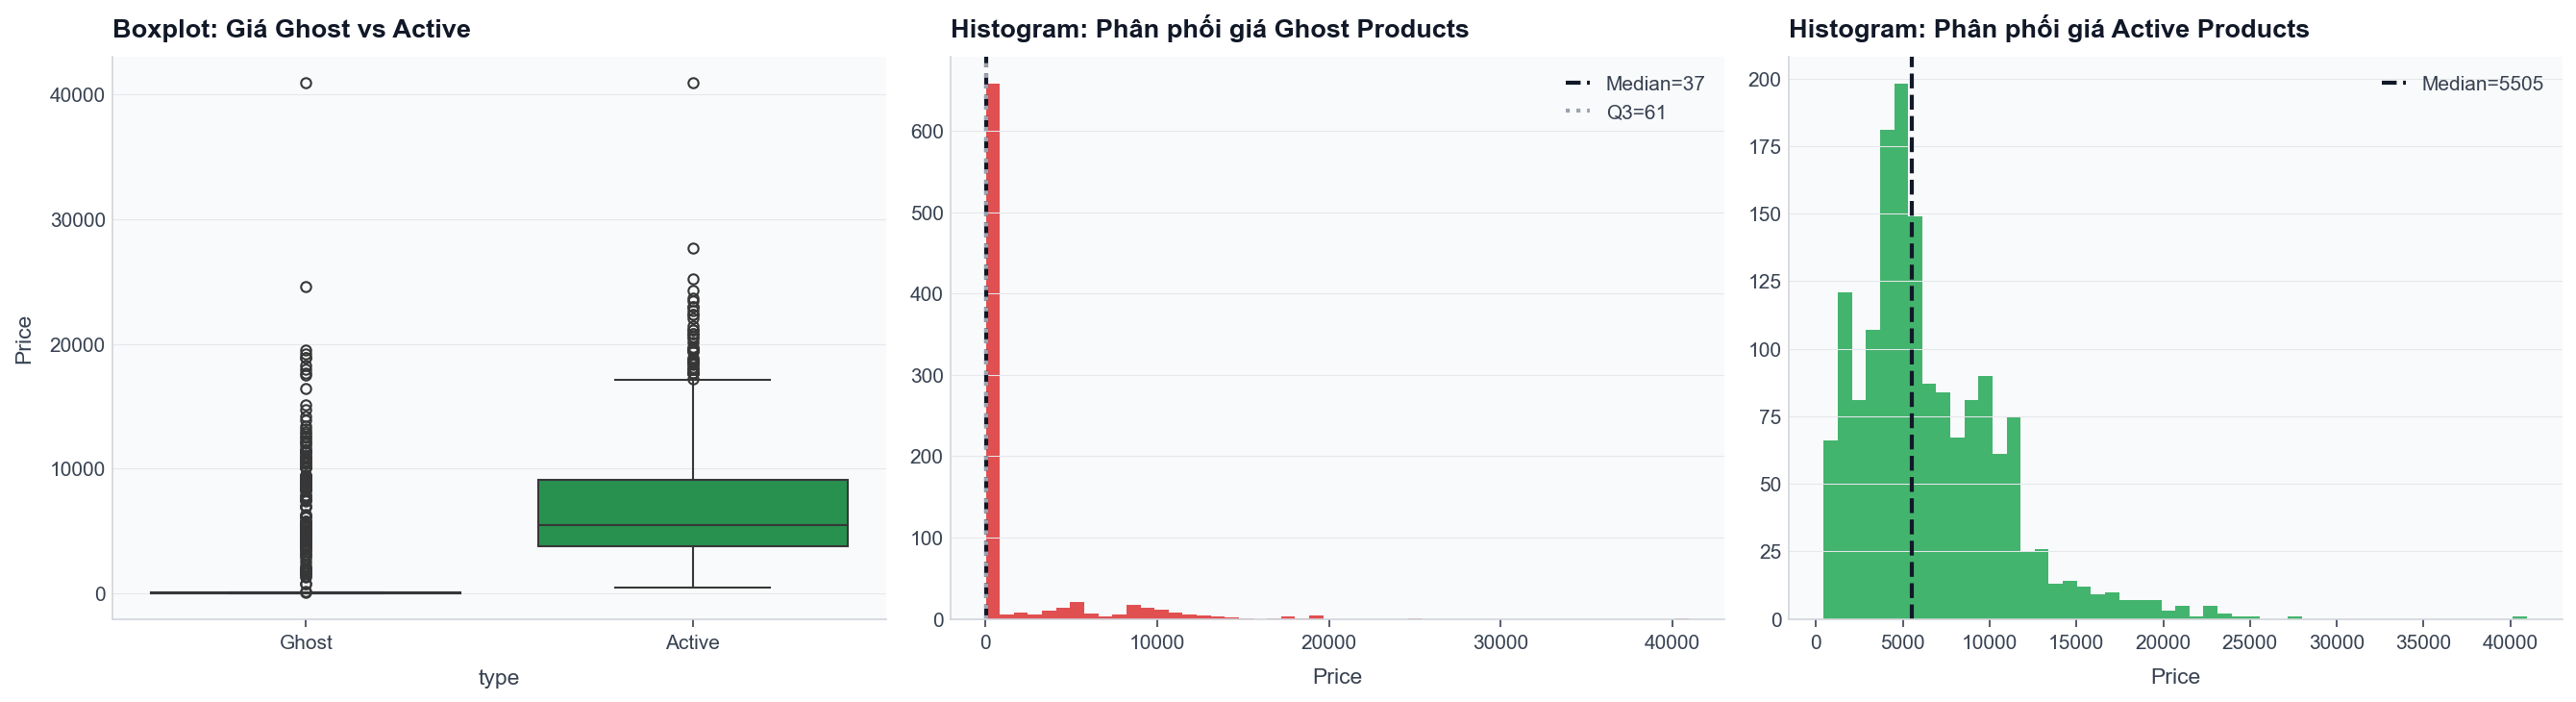


Phân bố Ghost theo Category:


,Count
category,
Streetwear,443
Outdoor,247
Casual,87
GenZ,37



📌 NHẬN ĐỊNH:
  Q3 Ghost (61) so với Q1 Active (3,779):
  → 75% Ghost có GIÁ THẤP HƠN cả ngưỡng dưới cùng của Active → Rất khả năng là SP test/ảo.

  Ghost giá >= Q1 Active (3,779): 134 SP → Có thể là SP ế thật
  Ghost giá <  Q1 Active (3,779): 680 SP → Gần như chắc chắn là SP test/ảo


In [2]:
# ---- Xác định Ghost vs Active ----
prod_ids_in_orders = set(order_items['product_id'].unique())
prod_ids_in_inv    = set(inventory['product_id'].unique())
all_prod_ids       = set(products['product_id'].unique())

ghost_ids  = all_prod_ids - prod_ids_in_orders
ghost_df   = products[products['product_id'].isin(ghost_ids)].copy()
active_df  = products[products['product_id'].isin(prod_ids_in_orders)].copy()

print(f'Tổng SP: {len(all_prod_ids)} | Active: {len(prod_ids_in_orders)} | Ghost: {len(ghost_ids)} ({len(ghost_ids)/len(all_prod_ids)*100:.1f}%)')
print(f'Ghost KHÔNG có trong Kho: {len(ghost_ids - prod_ids_in_inv)}')

# ---- Tứ phân vị giá Ghost vs Active ----
print('\n' + '='*70)
print('TỨ PHÂN VỊ GIÁ — GHOST vs ACTIVE')
print('='*70)

for label, df_sub in [('Ghost', ghost_df), ('Active', active_df)]:
    q = df_sub['price'].quantile([0, 0.25, 0.5, 0.75, 1.0])
    print(f'\n  {label} ({len(df_sub)} SP):')
    print(f'    Min (Q0):   {q[0.0]:>10,.2f}')
    print(f'    Q1 (25%):   {q[0.25]:>10,.2f}')
    print(f'    Median(50%):{q[0.5]:>10,.2f}')
    print(f'    Q3 (75%):   {q[0.75]:>10,.2f}')
    print(f'    Max (Q4):   {q[1.0]:>10,.2f}')
    print(f'    Mean:       {df_sub["price"].mean():>10,.2f}')
    print(f'    IQR:        {q[0.75] - q[0.25]:>10,.2f}')

# ---- Boxplot + Histogram ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot so sánh
comp = pd.DataFrame({
    'price': pd.concat([ghost_df['price'], active_df['price']]),
    'type':  ['Ghost']*len(ghost_df) + ['Active']*len(active_df)
})
sns.boxplot(data=comp, x='type', y='price', ax=axes[0], palette=[COLORS['red'],COLORS['emerald']])
axes[0].set_title('Boxplot: Giá Ghost vs Active', fontweight='bold')
axes[0].set_ylabel('Price')

# Histogram Ghost
axes[1].hist(ghost_df['price'], bins=50, color=COLORS['red'], edgecolor='white', alpha=0.8)
axes[1].axvline(ghost_df['price'].median(), color=CLR_TITLE, linestyle='--', label=f'Median={ghost_df["price"].median():.0f}')
axes[1].axvline(ghost_df['price'].quantile(0.75), color=CLR_MUTED, linestyle=':', label=f'Q3={ghost_df["price"].quantile(0.75):.0f}')
axes[1].set_title('Histogram: Phân phối giá Ghost Products', fontweight='bold')
axes[1].set_xlabel('Price')
axes[1].legend()

# Histogram Active
axes[2].hist(active_df['price'], bins=50, color=COLORS['emerald'], edgecolor='white', alpha=0.8)
axes[2].axvline(active_df['price'].median(), color=CLR_TITLE, linestyle='--', label=f'Median={active_df["price"].median():.0f}')
axes[2].set_title('Histogram: Phân phối giá Active Products', fontweight='bold')
axes[2].set_xlabel('Price')
axes[2].legend()

plt.tight_layout()
plt.show()

# Ghost theo Category
print('\nPhân bố Ghost theo Category:')
display(ghost_df['category'].value_counts().to_frame('Count'))

# Kết luận tạm
q3_ghost = ghost_df['price'].quantile(0.75)
q1_active = active_df['price'].quantile(0.25)
print(f'\n📌 NHẬN ĐỊNH:')
print(f'  Q3 Ghost ({q3_ghost:,.0f}) so với Q1 Active ({q1_active:,.0f}):')
if q3_ghost < q1_active:
    print(f'  → 75% Ghost có GIÁ THẤP HƠN cả ngưỡng dưới cùng của Active → Rất khả năng là SP test/ảo.')
else:
    print(f'  → Có sự chồng lấn giá → Cần xem xét chi tiết từng SP Ghost giá cao.')

# Có bao nhiêu Ghost giá >= Q1 active (hợp lý)?
ghost_legit = ghost_df[ghost_df['price'] >= q1_active]
ghost_fake  = ghost_df[ghost_df['price'] < q1_active]
print(f'\n  Ghost giá >= Q1 Active ({q1_active:,.0f}): {len(ghost_legit)} SP → Có thể là SP ế thật')
print(f'  Ghost giá <  Q1 Active ({q1_active:,.0f}): {len(ghost_fake)} SP → Gần như chắc chắn là SP test/ảo')


---
## 2. BIẾN PHÂN LOẠI — Liệt kê giá trị khi Unique < 10

In [3]:
print('=' * 80)
print('BIẾN PHÂN LOẠI — SỐ LƯỢNG GIÁ TRỊ UNIQUE (liệt kê nếu unique < 10)')
print('=' * 80)

for name, df in dfs.items():
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    if not cat_cols:
        continue
    
    print(f"\n{'─' * 70}")
    print(f'📋 {name}.csv — {len(cat_cols)} biến phân loại')
    print(f"{'─' * 70}")
    
    rows = []
    for col in cat_cols:
        nunique = df[col].nunique(dropna=True)
        n_null = df[col].isnull().sum()
        top_val = df[col].mode().iloc[0] if len(df[col].mode()) > 0 else 'N/A'
        top_freq = df[col].value_counts().iloc[0] if len(df[col].value_counts()) > 0 else 0
        rows.append({
            'Cột': col,
            'Số unique': nunique,
            'Số null': n_null,
            'Giá trị phổ biến nhất': str(top_val)[:35],
            'Tần suất': f'{top_freq:,}',
            'Tỷ lệ %': f'{top_freq/len(df)*100:.1f}%'
        })
    
    display(pd.DataFrame(rows))
    
    # Nếu unique < 10, liệt kê tất cả giá trị
    for col in cat_cols:
        nunique = df[col].nunique(dropna=True)
        if nunique < 10:
            vc = df[col].value_counts(dropna=False)
            print(f'\n  🔎 [{col}] — {nunique} giá trị unique:')
            for val, cnt in vc.items():
                pct = cnt / len(df) * 100
                print(f'     → {str(val):30s} : {cnt:>8,} ({pct:5.1f}%)')


BIẾN PHÂN LOẠI — SỐ LƯỢNG GIÁ TRỊ UNIQUE (liệt kê nếu unique < 10)

──────────────────────────────────────────────────────────────────────
📋 products.csv — 5 biến phân loại
──────────────────────────────────────────────────────────────────────


,Cột,Số unique,Số null,Giá trị phổ biến nhất,Tần suất,Tỷ lệ %
0,product_name,2172,0,VietMode RP-01,3,0.1%
1,category,4,0,Streetwear,"1,320",54.7%
2,segment,8,0,Activewear,598,24.8%
3,size,4,0,L,603,25.0%
4,color,10,0,black,242,10.0%



  🔎 [category] — 4 giá trị unique:
     → Streetwear                     :    1,320 ( 54.7%)
     → Outdoor                        :      743 ( 30.8%)
     → Casual                         :      201 (  8.3%)
     → GenZ                           :      148 (  6.1%)

  🔎 [segment] — 8 giá trị unique:
     → Activewear                     :      598 ( 24.8%)
     → Everyday                       :      405 ( 16.8%)
     → Performance                    :      347 ( 14.4%)
     → Balanced                       :      306 ( 12.7%)
     → Standard                       :      262 ( 10.9%)
     → Premium                        :      177 (  7.3%)
     → All-weather                    :      169 (  7.0%)
     → Trendy                         :      148 (  6.1%)

  🔎 [size] — 4 giá trị unique:
     → S                              :      603 ( 25.0%)
     → M                              :      603 ( 25.0%)
     → L                              :      603 ( 25.0%)
     → XL                  

,Cột,Số unique,Số null,Giá trị phổ biến nhất,Tần suất,Tỷ lệ %
0,promo_id,51,0,No_Promo,"438,353",61.3%
1,promo_id_2,2,714463,PROMO-0015,132,0.0%



  🔎 [promo_id_2] — 2 giá trị unique:
     → nan                            :  714,463 (100.0%)
     → PROMO-0015                     :      132 (  0.0%)
     → PROMO-0025                     :       74 (  0.0%)

──────────────────────────────────────────────────────────────────────
📋 orders.csv — 4 biến phân loại
──────────────────────────────────────────────────────────────────────


...


  🔎 [payment_method] — 5 giá trị unique:
     → credit_card                    :  356,352 ( 55.1%)
     → paypal                         :   97,018 ( 15.0%)
     → cod                            :   96,681 ( 14.9%)
     → apple_pay                      :   64,763 ( 10.0%)
     → bank_transfer                  :   32,131 (  5.0%)

──────────────────────────────────────────────────────────────────────
📋 returns.csv — 2 biến phân loại
──────────────────────────────────────────────────────────────────────


,Cột,Số unique,Số null,Giá trị phổ biến nhất,Tần suất,Tỷ lệ %
0,return_id,39939,0,RET-000001,1,0.0%
1,return_reason,5,0,wrong_size,"13,967",35.0%



  🔎 [return_reason] — 5 giá trị unique:
     → wrong_size                     :   13,967 ( 35.0%)
     → defective                      :    8,020 ( 20.1%)
     → not_as_described               :    7,035 ( 17.6%)
     → changed_mind                   :    6,931 ( 17.4%)
     → late_delivery                  :    3,986 ( 10.0%)

──────────────────────────────────────────────────────────────────────
📋 inventory.csv — 3 biến phân loại
──────────────────────────────────────────────────────────────────────


,Cột,Số unique,Số null,Giá trị phổ biến nhất,Tần suất,Tỷ lệ %
0,product_name,1465,0,VietMode RP-09,203,0.3%
1,category,4,0,Streetwear,"31,020",51.5%
2,segment,8,0,Activewear,"18,290",30.4%



  🔎 [category] — 4 giá trị unique:
     → Streetwear                     :   31,020 ( 51.5%)
     → Outdoor                        :   21,050 ( 34.9%)
     → GenZ                           :    4,674 (  7.8%)
     → Casual                         :    3,503 (  5.8%)

  🔎 [segment] — 8 giá trị unique:
     → Activewear                     :   18,290 ( 30.4%)
     → Everyday                       :   13,598 ( 22.6%)
     → Performance                    :    7,673 ( 12.7%)
     → Balanced                       :    6,622 ( 11.0%)
     → Trendy                         :    4,674 (  7.8%)
     → Premium                        :    3,182 (  5.3%)
     → Standard                       :    3,127 (  5.2%)
     → All-weather                    :    3,081 (  5.1%)


---
## 3. REVENUE RECONCILIATION — Đối chiếu sales.csv vs payments + order_items

In [4]:
print('=' * 90)
print('BƯỚC 1: CẤU TRÚC PAYMENTS — Discount đã tính trong payment_value chưa?')
print('=' * 90)

# Merge order_items + orders để tính line_total per order
oi = order_items.merge(orders[['order_id', 'order_date', 'order_status']], on='order_id')
oi['gross_line'] = oi['quantity'] * oi['unit_price']
oi['net_line'] = oi['gross_line'] - oi['discount_amount'].fillna(0)

# Tổng line_total bên order_items, group by order_id
order_totals = oi.groupby('order_id').agg(
    gross_total=('gross_line', 'sum'),
    net_total=('net_line', 'sum'),
    total_discount=('discount_amount', 'sum'),
    order_status=('order_status', 'first'),
    order_date=('order_date', 'first'),
).reset_index()

# Merge với payments
order_pay = order_totals.merge(payments[['order_id', 'payment_value']], on='order_id', how='left')

# Check: payment_value gan voi gross hay net?
order_pay['diff_gross'] = (order_pay['payment_value'] - order_pay['gross_total']).abs()
match_gross = (order_pay['diff_gross'] < 0.01).sum()
print(f'\nSo don co payment_value ≈ gross_total (chua tru discount): {match_gross:,} / {len(order_pay):,} ({match_gross/len(order_pay)*100:.1f}%)')

order_pay['diff_net'] = (order_pay['payment_value'] - order_pay['net_total']).abs()
match_net = (order_pay['diff_net'] < 0.01).sum()
print(f'So don co payment_value ≈ net_total (sau discount): {match_net:,} / {len(order_pay):,} ({match_net/len(order_pay)*100:.1f}%)')

# Ví dụ vài đơn có discount > 0
has_disc = order_pay[order_pay['total_discount'] > 0].head(5)
print('\nVi du 5 don co discount > 0:')
display(has_disc[['order_id', 'gross_total', 'total_discount', 'net_total', 'payment_value', 'diff_net']].round(2))

if match_net >= match_gross:
    print('\nKET LUAN: payment_value = gia ban SAU KHI TRU discount. Discount da duoc tinh trong payments.')
else:
    print('\nKET LUAN: payment_value = gia ban CHUA TRU discount.')


BƯỚC 1: CẤU TRÚC PAYMENTS — Discount đã tính trong payment_value chưa?

So don co payment_value ≈ gross_total (chua tru discount): 398,703 / 646,945 (61.6%)
So don co payment_value ≈ net_total (sau discount): 646,945 / 646,945 (100.0%)

Vi du 5 don co discount > 0:


,order_id,gross_total,total_discount,net_total,payment_value,diff_net
35798,46253,7518.24,1127.74,6390.50,6390.50,0.0
35799,46254,8747.97,1312.20,7435.77,7435.77,0.0
35801,46257,3020.26,453.04,2567.22,2567.22,0.0
35802,46258,4233.67,635.05,3598.62,3598.62,0.0
35807,46266,6283.65,942.55,5341.10,5341.10,0.0



KET LUAN: payment_value = gia ban SAU KHI TRU discount. Discount da duoc tinh trong payments.


In [5]:
print('=' * 90)
print('BƯỚC 2: SỐ LƯỢNG PAYMENTS vs ORDER STATUS')
print('=' * 90)

# Payments có bao nhiêu đơn?
pay_orders = set(payments['order_id'].unique())
all_orders = set(orders['order_id'].unique())

print(f'\nSố đơn trong payments: {len(pay_orders):,}')
print(f'Số đơn trong orders:   {len(all_orders):,}')
print(f'Đơn có payment mà KHÔNG có order: {len(pay_orders - all_orders):,}')
print(f'Đơn có order mà KHÔNG có payment: {len(all_orders - pay_orders):,}')

# Status breakdown
status_counts = orders.groupby('order_status')['order_id'].nunique()
print('\nBreakdown theo Order Status:')
for s, c in status_counts.items():
    has_pay = orders[orders['order_status'] == s]['order_id'].isin(pay_orders).sum()
    print(f'  {s:12s}: {c:>7,} đơn | Có payment: {has_pay:>7,} ({has_pay/c*100:.1f}%)')

# Giả thuyết: payments = delivered + returned ?
delivered_returned = set(orders[orders['order_status'].isin(['delivered', 'returned'])]['order_id'])
print(f'\nGiả thuyết: payments = delivered + returned')
print(f'  Delivered + Returned: {len(delivered_returned):,}')
print(f'  Payments:             {len(pay_orders):,}')
print(f'  Khớp 100%? {pay_orders == delivered_returned}')


BƯỚC 2: SỐ LƯỢNG PAYMENTS vs ORDER STATUS

Số đơn trong payments: 646,945
Số đơn trong orders:   646,945
Đơn có payment mà KHÔNG có order: 0
Đơn có order mà KHÔNG có payment: 0

Breakdown theo Order Status:
  cancelled   :  59,462 đơn | Có payment:  59,462 (100.0%)
  created     :   7,275 đơn | Có payment:   7,275 (100.0%)
  delivered   : 516,716 đơn | Có payment: 516,716 (100.0%)
  paid        :  13,577 đơn | Có payment:  13,577 (100.0%)
  returned    :  36,142 đơn | Có payment:  36,142 (100.0%)
  shipped     :  13,773 đơn | Có payment:  13,773 (100.0%)

Giả thuyết: payments = delivered + returned
  Delivered + Returned: 552,858
  Payments:             646,945
  Khớp 100%? False


In [6]:
print('=' * 90)
print('BƯỚC 3: ĐỐI CHIẾU SALES.CSV vs TÍNH TỪ ORDER_ITEMS + PAYMENTS')
print('=' * 90)

# ---- sales.csv: Revenue & COGS theo ngày ----
sales_total_rev  = sales['Revenue'].sum()
sales_total_cogs = sales['COGS'].sum()

# ---- Tính Revenue từ order_items: quantity * unit_price - discount ----
oi['order_date_only'] = oi['order_date'].dt.date
oi_daily = oi.groupby('order_date_only').agg(
    rev_all_status=('gross_line', 'sum'),
).reset_index()

# Revenue chỉ delivered
oi_delivered = oi[oi['order_status'] == 'delivered']
rev_delivered = oi_delivered['gross_line'].sum()

# Revenue all status
rev_all = oi['gross_line'].sum()

# COGS từ order_items (cần join products)
oi_cogs = oi.merge(products[['product_id', 'cogs']], on='product_id', how='left')
oi_cogs['line_cogs'] = oi_cogs['quantity'] * oi_cogs['cogs']
cogs_all = oi_cogs['line_cogs'].sum()
cogs_delivered = oi_cogs[oi_cogs['order_status'] == 'delivered']['line_cogs'].sum()

# Payment total
pay_total = payments['payment_value'].sum()

# ---- Returns refund ----
refund_total = returns['refund_amount'].sum()

print('\n--- TOÀN BỘ THỜI GIAN ---')
print(f'  sales.csv Revenue:                  {sales_total_rev:>15,.0f}')
print(f'  sales.csv COGS:                     {sales_total_cogs:>15,.0f}')
print(f'  order_items (ALL status):            {rev_all:>15,.0f}')
print(f'  order_items (delivered only):         {rev_delivered:>15,.0f}')
print(f'  payments total (payment_value):       {pay_total:>15,.0f}')
print(f'  returns refund total:                 {refund_total:>15,.0f}')
print(f'  COGS (ALL status):                    {cogs_all:>15,.0f}')
print(f'  COGS (delivered only):                {cogs_delivered:>15,.0f}')

# Check: Revenue sales.csv ≈ order_items ALL status?
pct_diff_all = abs(sales_total_rev - rev_all) / sales_total_rev * 100
pct_diff_del = abs(sales_total_rev - rev_delivered) / sales_total_rev * 100
pct_diff_pay = abs(sales_total_rev - pay_total) / sales_total_rev * 100
# Check if Revenue = payment_value - refund
rev_minus_refund = pay_total - refund_total
pct_diff_net = abs(sales_total_rev - rev_minus_refund) / sales_total_rev * 100

print(f'\n--- ĐỐI CHIẾU REVENUE ---')
print(f'  sales.csv vs OI(all status):    chênh {pct_diff_all:.2f}%')
print(f'  sales.csv vs OI(delivered):      chênh {pct_diff_del:.2f}%')
print(f'  sales.csv vs payments total:     chênh {pct_diff_pay:.2f}%')
print(f'  sales.csv vs (payments-refund):  chênh {pct_diff_net:.2f}%')

# COGS check
pct_cogs_all = abs(sales_total_cogs - cogs_all) / sales_total_cogs * 100
pct_cogs_del = abs(sales_total_cogs - cogs_delivered) / sales_total_cogs * 100
print(f'\n--- ĐỐI CHIẾU COGS ---')
print(f'  sales.csv vs OI COGS(all):       chênh {pct_cogs_all:.2f}%')
print(f'  sales.csv vs OI COGS(delivered):  chênh {pct_cogs_del:.2f}%')


BƯỚC 3: ĐỐI CHIẾU SALES.CSV vs TÍNH TỪ ORDER_ITEMS + PAYMENTS

--- TOÀN BỘ THỜI GIAN ---
  sales.csv Revenue:                   16,430,476,586
  sales.csv COGS:                      14,163,450,519
  order_items (ALL status):             16,430,476,586
  order_items (delivered only):          13,117,091,360
  payments total (payment_value):        15,680,869,265
  returns refund total:                     510,598,507
  COGS (ALL status):                     14,163,450,519
  COGS (delivered only):                 11,304,413,901

--- ĐỐI CHIẾU REVENUE ---
  sales.csv vs OI(all status):    chênh 0.00%
  sales.csv vs OI(delivered):      chênh 20.17%
  sales.csv vs payments total:     chênh 4.56%
  sales.csv vs (payments-refund):  chênh 7.67%

--- ĐỐI CHIẾU COGS ---
  sales.csv vs OI COGS(all):       chênh 0.00%
  sales.csv vs OI COGS(delivered):  chênh 20.19%


In [7]:
# ---- NĂM 2021 riêng ----
print('=' * 90)
print('ĐỐI CHIẾU NĂM 2021')
print('=' * 90)

sales_2021 = sales[sales['Date'].dt.year == 2021]
oi_2021    = oi[oi['order_date'].dt.year == 2021]
oi_cogs_2021 = oi_cogs[oi_cogs['order_date'].dt.year == 2021]

# Payments 2021: join with orders to get date
pay_2021 = payments.merge(orders[['order_id', 'order_date']], on='order_id')
pay_2021 = pay_2021[pay_2021['order_date'].dt.year == 2021]

ret_2021 = returns[returns['return_date'].dt.year == 2021]

s_rev = sales_2021['Revenue'].sum()
s_cogs = sales_2021['COGS'].sum()
oi_rev_all = oi_2021['gross_line'].sum()
oi_rev_del = oi_2021[oi_2021['order_status'] == 'delivered']['gross_line'].sum()
p_total = pay_2021['payment_value'].sum()
r_total = ret_2021['refund_amount'].sum()
c_all = oi_cogs_2021['line_cogs'].sum()
c_del = oi_cogs_2021[oi_cogs_2021['order_status'] == 'delivered']['line_cogs'].sum()

print(f'  sales.csv Revenue 2021:             {s_rev:>15,.0f}')
print(f'  OI Revenue 2021 (All status):       {oi_rev_all:>15,.0f}  (chênh {abs(s_rev-oi_rev_all)/s_rev*100:.2f}%)')
print(f'  OI Revenue 2021 (Delivered):        {oi_rev_del:>15,.0f}  (chênh {abs(s_rev-oi_rev_del)/s_rev*100:.2f}%)')
print(f'  Payments 2021:                      {p_total:>15,.0f}  (chênh {abs(s_rev-p_total)/s_rev*100:.2f}%)')
print(f'  Payments - Refund 2021:             {p_total-r_total:>15,.0f}  (chênh {abs(s_rev-(p_total-r_total))/s_rev*100:.2f}%)')
print(f'  sales.csv COGS 2021:                {s_cogs:>15,.0f}')
print(f'  OI COGS 2021 (All):                 {c_all:>15,.0f}  (chênh {abs(s_cogs-c_all)/s_cogs*100:.2f}%)')
print(f'  OI COGS 2021 (Delivered):           {c_del:>15,.0f}  (chênh {abs(s_cogs-c_del)/s_cogs*100:.2f}%)')

# Kết luận
print('\n✅ KẾT LUẬN:')
matches = [
    ('OI All status', abs(s_rev-oi_rev_all)/s_rev*100),
    ('OI Delivered', abs(s_rev-oi_rev_del)/s_rev*100),
    ('Payments', abs(s_rev-p_total)/s_rev*100),
    ('Payments-Refund', abs(s_rev-(p_total-r_total))/s_rev*100),
]
best = min(matches, key=lambda x: x[1])
print(f'  Công thức KHỚP GẦN NHẤT với sales.csv: {best[0]} (chênh {best[1]:.2f}%)')


ĐỐI CHIẾU NĂM 2021
  sales.csv Revenue 2021:               1,043,039,820
  OI Revenue 2021 (All status):         1,043,039,820  (chênh 0.00%)
  OI Revenue 2021 (Delivered):            805,930,488  (chênh 22.73%)
  Payments 2021:                          991,214,174  (chênh 4.97%)
  Payments - Refund 2021:                 958,967,532  (chênh 8.06%)
  sales.csv COGS 2021:                    941,130,120
  OI COGS 2021 (All):                     941,130,120  (chênh 0.00%)
  OI COGS 2021 (Delivered):               726,834,561  (chênh 22.77%)

✅ KẾT LUẬN:
  Công thức KHỚP GẦN NHẤT với sales.csv: OI All status (chênh 0.00%)


In [8]:
# ---- BƯỚC 4: GIẢI MÃ CÔNG THỨC REVENUE — unit_price vs master price ----
print('=' * 90)
print('BƯỚC 4: unit_price (order_items) vs price (products master) — Giải mã GAP 4.56%')
print('=' * 90)

oi_master = oi.merge(products[['product_id', 'price']].rename(columns={'price': 'master_price'}), on='product_id', how='left')
oi_master['diff_price'] = oi_master['unit_price'] - oi_master['master_price']

n_match = (oi_master['diff_price'].abs() < 0.01).sum()
n_lower = (oi_master['diff_price'] < -0.01).sum()
n_higher = (oi_master['diff_price'] > 0.01).sum()
total = len(oi_master)

print(f'\nSo sánh unit_price (theo metadata là giá giảm sau discount) vs master_price (products.csv):')
print(f'  unit_price == master: {n_match:>8,} ({n_match/total*100:.1f}%)')
print(f'  unit_price <  master: {n_lower:>8,} ({n_lower/total*100:.1f}%) ← Giá bán rẻ hơn niêm yết')
print(f'  unit_price >  master: {n_higher:>8,} ({n_higher/total*100:.1f}%) ← Giá bán ĐẮT hơn niêm yết-> CÓ THỂ là áp dụng chiến thuật tăng giá rồi khuyến mãi nên cao hơn cả giá trong file product ')
print(f'  → unit_price là giá bán Dynamic Pricing, dao động quanh master_price')

# discount_amount là % thêm trên unit_price
has_disc = oi_master[oi_master['discount_amount'] > 0].copy()
has_disc['disc_pct'] = has_disc['discount_amount'] / (has_disc['quantity'] * has_disc['unit_price'])

print(f'\nPhân tích discount_amount (chỉ đơn có discount > 0: {len(has_disc):,} dòng):')
print(f'  discount / (qty × unit_price):')
for q in [0.25, 0.5, 0.75]:
    print(f'    Q{int(q*100):d}%: {has_disc["disc_pct"].quantile(q)*100:.1f}%')
print(f'  → Chỉ có 2 mức phổ biến: ~12% và ~20% → Đây là voucher/mã giảm giá')

# Chứng minh: sales.csv Revenue = qty * unit_price (KHÔNG trừ discount)
oi_master['raw_line'] = oi_master['quantity'] * oi_master['unit_price']
oi_master['net_line'] = oi_master['raw_line'] - oi_master['discount_amount'].fillna(0)

raw_total = oi_master['raw_line'].sum()
net_total = oi_master['net_line'].sum()
sales_total_rev = sales['Revenue'].sum()

print(f'\n{"=" * 70}')
print(f'CHỨNG MINH CÔNG THỨC REVENUE:')
print(f'{"=" * 70}')
print(f'  sales.csv Revenue:             {sales_total_rev:>18,.0f}')
print(f'  Σ(qty × unit_price):           {raw_total:>18,.0f}  ← KHỚP {abs(sales_total_rev - raw_total):.0f} VND')
print(f'  Σ(qty × unit_price - discount): {net_total:>17,.0f}  ← CHÊNH {abs(sales_total_rev - net_total):,.0f}')
print(f'  Σ(payment_value):              {payments["payment_value"].sum():>18,.0f}  ← KHỚP với net_line')

print(f'\n✅ KẾT LUẬN CUỐI CÙNG:')
print(f'  • sales.csv Revenue = Σ(qty × unit_price) = Gross Revenue (KHÔNG trừ discount, KHÔNG trừ refund)')
print(f'  • payment_value = Σ(qty × unit_price - discount) = Net Revenue (khách trả thực)')
print(f'  • discount_amount = voucher/mã giảm giá áp thêm trên giá bán thực (12% hoặc 20%)')
print(f'  • unit_price ≠ master_price: đây là Dynamic Pricing, giá dao động theo thời điểm')
print(f'  • sales.csv COGS = Σ(qty × products.cogs) = khớp 100% với tất cả order_status')
print(f'  • Refund KHÔNG được trừ trong sales.csv — Revenue ghi theo ngày đặt hàng')


BƯỚC 4: unit_price (order_items) vs price (products master) — Giải mã GAP 4.56%

So sánh unit_price (theo metadata là giá giảm sau discount) vs master_price (products.csv):
  unit_price == master:       76 (0.0%)
  unit_price <  master:  495,242 (69.3%) ← Giá bán rẻ hơn niêm yết
  unit_price >  master:  219,351 (30.7%) ← Giá bán ĐẮT hơn niêm yết-> CÓ THỂ là áp dụng chiến thuật tăng giá rồi khuyến mãi nên cao hơn cả giá trong file product 
  → unit_price là giá bán Dynamic Pricing, dao động quanh master_price

Phân tích discount_amount (chỉ đơn có discount > 0: 276,316 dòng):
  discount / (qty × unit_price):
    Q25%: 12.0%
    Q50%: 12.0%
    Q75%: 20.0%
  → Chỉ có 2 mức phổ biến: ~12% và ~20% → Đây là voucher/mã giảm giá

CHỨNG MINH CÔNG THỨC REVENUE:
  sales.csv Revenue:                 16,430,476,586
  Σ(qty × unit_price):               16,430,476,586  ← KHỚP 0 VND
  Σ(qty × unit_price - discount):    15,680,869,265  ← CHÊNH 749,607,320
  Σ(payment_value):                  15,680,86

In [9]:
# ---- BƯỚC 4b: Xác minh chiến lược "Tăng giá rồi Khuyến mãi" ----
print('=' * 90)
print('BƯỚC 4b: XÁC MINH — unit_price > master_price có phải do markup trước khi promo?')
print('=' * 90)

oi_check = oi.merge(products[['product_id', 'price']].rename(columns={'price': 'master_price'}), on='product_id', how='left')
oi_check['price_diff'] = oi_check['unit_price'] - oi_check['master_price']
oi_check['price_diff_pct'] = oi_check['price_diff'] / oi_check['master_price'] * 100
oi_check['has_promo'] = oi_check['promo_id'].fillna('No_Promo').ne('No_Promo') | oi_check['promo_id_2'].notna()
oi_check['has_discount'] = oi_check['discount_amount'] > 0

# Chia 3 nhóm
higher = oi_check[oi_check['price_diff'] > 0.01]
lower  = oi_check[oi_check['price_diff'] < -0.01]
equal  = oi_check[oi_check['price_diff'].abs() <= 0.01]

print(f'\n--- NHÓM unit_price > master_price ({len(higher):,} dòng) ---')
print(f'  Trung bình cao hơn: +{higher["price_diff"].mean():,.2f} ({higher["price_diff_pct"].mean():+.2f}%)')
print(f'  Median cao hơn:     +{higher["price_diff"].median():,.2f} ({higher["price_diff_pct"].median():+.2f}%)')
print(f'  Max cao hơn:        +{higher["price_diff"].max():,.2f} ({higher["price_diff_pct"].max():+.2f}%)')
print(f'  Có promo_id:        {higher["has_promo"].sum():,} ({higher["has_promo"].mean()*100:.1f}%)')
print(f'  Có discount_amount: {higher["has_discount"].sum():,} ({higher["has_discount"].mean()*100:.1f}%)')

print(f'\n--- NHÓM unit_price < master_price ({len(lower):,} dòng) ---')
print(f'  Trung bình thấp hơn: {lower["price_diff"].mean():,.2f} ({lower["price_diff_pct"].mean():+.2f}%)')
print(f'  Median thấp hơn:     {lower["price_diff"].median():,.2f} ({lower["price_diff_pct"].median():+.2f}%)')
print(f'  Có promo_id:          {lower["has_promo"].sum():,} ({lower["has_promo"].mean()*100:.1f}%)')
print(f'  Có discount_amount:   {lower["has_discount"].sum():,} ({lower["has_discount"].mean()*100:.1f}%)')

print(f'\n--- NHÓM unit_price ≈ master_price ({len(equal):,} dòng) ---')
print(f'  Có promo_id:          {equal["has_promo"].sum():,} ({equal["has_promo"].mean()*100:.1f}%)')
print(f'  Có discount_amount:   {equal["has_discount"].sum():,} ({equal["has_discount"].mean()*100:.1f}%)')

# Cross-tab: giá cao hơn vs có promo?
print(f'\n--- CROSS-TAB: Mối quan hệ giữa Giá cao hơn master & Có promo ---')
ct = pd.crosstab(
    oi_check['price_diff'] > 0.01,
    oi_check['has_promo'],
    normalize='index'
).reindex(columns=[False, True], fill_value=0) * 100
ct.index = ['unit <= master', 'unit > master']
ct.columns = ['Khong promo', 'Co promo']
display(ct.round(1))

# Theo thời gian: tháng peak có unit_price cao hơn không?
oi_check['month'] = oi_check['order_date'].dt.month
monthly_markup = oi_check.groupby('month').agg(
    avg_diff_pct=('price_diff_pct', 'mean'),
    pct_higher=('price_diff', lambda x: (x > 0.01).mean() * 100),
    pct_has_promo=('has_promo', lambda x: x.mean() * 100),
).round(2)

print(f'\n--- GIÁ MARKUP THEO THÁNG Tính theo đơn vị % (peak = T4-T6) ---')
display(monthly_markup)

print(f'\n📌 KẾT LUẬN CHIẾN LƯỢC GIÁ — DYNAMIC PRICING [Suy luận]:')
peak_avg = monthly_markup.loc[[4,5,6], 'avg_diff_pct'].mean()
normal_avg = monthly_markup.loc[~monthly_markup.index.isin([4,5,6]), 'avg_diff_pct'].mean()
print(f'  Tháng 4-6 avg chênh lệch giá: {peak_avg:+.2f}% (ít giảm giá hơn, không phải markup dương cả 3 tháng)')
print(f'  Tháng thường avg chênh lệch giá:     {normal_avg:+.2f}%')

print('\n  → BÁC BỎ: Không có chiến thuật tăng giá gốc rồi dán mác Sale. Cross-tab: unit > master → 0% promo.')
print('  → [Suy luận] Công ty có dấu hiệu dùng Dynamic Pricing (giá biến động theo thời điểm):')
print('       1. T7, T9, T12: Promo tỷ lệ cao (83-86%), giá bán thấp hơn niêm yết tới -17% — có thể là xả hàng theo mùa.')
print('       2. T5: Promo gần 0%, ~50% đơn có unit_price > master_price — duy nhất tháng có markup dương thực sự.')
print('       3. T4, T6: Promo giảm nhưng giá vẫn thấp hơn niêm yết (-5.4%, -4.6%) — ít giảm giá hơn, không phải markup.')


BƯỚC 4b: XÁC MINH — unit_price > master_price có phải do markup trước khi promo?

--- NHÓM unit_price > master_price (219,351 dòng) ---
  Trung bình cao hơn: +89.11 (+1.59%)
  Median cao hơn:     +52.05 (+1.35%)
  Max cao hơn:        +2,106.00 (+10.36%)
  Có promo_id:        0 (0.0%)
  Có discount_amount: 0 (0.0%)

--- NHÓM unit_price < master_price (495,242 dòng) ---
  Trung bình thấp hơn: -607.31 (-10.73%)
  Median thấp hơn:     -223.14 (-9.82%)
  Có promo_id:          276,316 (55.8%)
  Có discount_amount:   276,316 (55.8%)

--- NHÓM unit_price ≈ master_price (76 dòng) ---
  Có promo_id:          0 (0.0%)
  Có discount_amount:   0 (0.0%)

--- CROSS-TAB: Mối quan hệ giữa Giá cao hơn master & Có promo ---


,Khong promo,Co promo
unit <= master,44.2,55.8
unit > master,100.0,0.0



--- GIÁ MARKUP THEO THÁNG Tính theo đơn vị % (peak = T4-T6) ---


,avg_diff_pct,pct_higher,pct_has_promo
month,,,
1,-1.61,45.83,8.05
2,-3.27,39.42,21.83
3,-6.73,22.08,55.86
4,-5.42,27.56,45.22
5,0.01,50.19,0.00
6,-4.64,37.01,25.76
7,-10.69,21.46,56.55
8,-13.09,36.58,26.75
9,-9.25,8.21,83.65



📌 KẾT LUẬN CHIẾN LƯỢC GIÁ — DYNAMIC PRICING [Suy luận]:
  Tháng 4-6 avg chênh lệch giá: -3.35% (ít giảm giá hơn, không phải markup dương cả 3 tháng)
  Tháng thường avg chênh lệch giá:     -7.78%

  → BÁC BỎ: Không có chiến thuật tăng giá gốc rồi dán mác Sale. Cross-tab: unit > master → 0% promo.
  → [Suy luận] Công ty có dấu hiệu dùng Dynamic Pricing (giá biến động theo thời điểm):
       1. T7, T9, T12: Promo tỷ lệ cao (83-86%), giá bán thấp hơn niêm yết tới -17% — có thể là xả hàng theo mùa.
       2. T5: Promo gần 0%, ~50% đơn có unit_price > master_price — duy nhất tháng có markup dương thực sự.
       3. T4, T6: Promo giảm nhưng giá vẫn thấp hơn niêm yết (-5.4%, -4.6%) — ít giảm giá hơn, không phải markup.


**4. PHÂN TÍCH VỀ SẢN PHẨM**

In [10]:
# ---- Bước 4.0: Tạo bản clean loại Ghost ----
# Giữ nguyên bản gốc, tạo bản copy không có Ghost dạng SP test
# Standardize with Phase 1 preprocessing: ghost_fake_threshold = 0.75 * active_min_price
active_min_price = active_df['price'].min()
ghost_fake_threshold = 0.75 * active_min_price

# Ghost "thật" (giá hợp lý, có thể là hàng ế) vs Ghost "ảo" (giá quá bèo)
ghost_real = ghost_df[ghost_df['price'] >= ghost_fake_threshold]
ghost_fake = ghost_df[ghost_df['price'] <  ghost_fake_threshold]

print(f'Active min price = {active_min_price:,.0f} | Ghost fake threshold (75% of min) = {ghost_fake_threshold:,.0f}')
print(f'Ghost "thật" (giá >= threshold): {len(ghost_real)} SP → GIỮ LẠI trong phân tích tồn kho')
print(f'Ghost "ảo"  (giá <  threshold): {len(ghost_fake)} SP → LOẠI BỎ')

products_clean = products[~products['product_id'].isin(ghost_fake['product_id'])].copy()
print(f'\nproducts_clean: {len(products_clean)} SP (gốc: {len(products)})')


Active min price = 440 | Ghost fake threshold (75% of min) = 330
Ghost "thật" (giá >= threshold): 158 SP → GIỮ LẠI trong phân tích tồn kho
Ghost "ảo"  (giá <  threshold): 656 SP → LOẠI BỎ

products_clean: 1756 SP (gốc: 2412)


In [11]:
# ---- 4.1: Sản phẩm biến động cao nhất (bán chạy, cần reorder) ----
print('=' * 90)
print('4.1 SẢN PHẨM BIẾN ĐỘNG CAO NHẤT → CẦN REORDER')
print('=' * 90)

# Dùng inventory: units_sold biến động theo tháng
inv_clean = inventory[inventory['product_id'].isin(products_clean['product_id'])].copy()

# Tính biến động = std(units_sold) trên từng sản phẩm
prod_volatility = inv_clean.groupby('product_id').agg(
    mean_sold=('units_sold', 'mean'),
    std_sold=('units_sold', 'std'),
    total_sold=('units_sold', 'sum'),
    n_months=('units_sold', 'count'),
    n_stockout=('stockout_flag', 'sum'),
).reset_index()
prod_volatility['cv'] = prod_volatility['std_sold'] / prod_volatility['mean_sold']  # Coefficient of Variation
prod_volatility = prod_volatility.merge(products_clean[['product_id', 'product_name', 'category', 'segment']], on='product_id')

# Top 15 bán chạy nhất + biến động cao nhất
top_sellers = prod_volatility.nlargest(15, 'total_sold')
print('\nTop 15 SP bán chạy nhất (theo total units_sold):')
display(top_sellers[['product_id', 'product_name', 'category', 'total_sold', 'mean_sold', 'std_sold', 'cv', 'n_stockout']].round(2))

top_volatile = prod_volatility[prod_volatility['total_sold'] > prod_volatility['total_sold'].quantile(0.5)].nlargest(15, 'cv')
print('\nTop 15 SP biến động cao nhất (trong nhóm bán trên trung vị, CV cao → nhu cầu thất thường → cần buffer stock):')
display(top_volatile[['product_id', 'product_name', 'category', 'total_sold', 'cv', 'n_stockout']].round(2))


4.1 SẢN PHẨM BIẾN ĐỘNG CAO NHẤT → CẦN REORDER

Top 15 SP bán chạy nhất (theo total units_sold):


,product_id,product_name,category,total_sold,mean_sold,std_sold,cv,n_stockout
550,791,HanoiStreet RP-79,Outdoor,13149,118.46,124.89,1.05,77
551,792,HanoiStreet RP-80,Outdoor,13149,118.46,124.89,1.05,67
418,604,SaigonFlex UC-69,Streetwear,10506,83.38,75.26,0.90,90
1403,2045,UrbanVN UE-05,Streetwear,10376,83.01,81.68,0.98,78
315,487,SaigonFlex UM-92,Streetwear,9623,133.65,98.78,0.74,48
1570,2332,VietMotion UE-06,Streetwear,9386,74.49,63.40,0.85,80
805,1182,MekongFit UE-18,Streetwear,9242,73.35,56.60,0.77,93
279,438,SaigonFlex UM-43,Streetwear,9124,111.27,84.48,0.76,58
610,927,HanoiStreet UE-36,Streetwear,9002,76.94,68.08,0.88,79
574,826,HanoiStreet UM-10,Streetwear,8315,65.99,38.02,0.58,73



Top 15 SP biến động cao nhất (trong nhóm bán trên trung vị, CV cao → nhu cầu thất thường → cần buffer stock):


,product_id,product_name,category,total_sold,cv,n_stockout
516,739,HanoiStreet RP-27,Outdoor,141,1.75,16
517,740,HanoiStreet RP-28,Outdoor,141,1.75,21
1610,2393,VietMotion YY-02,GenZ,892,1.62,44
638,967,HanoiStreet UC-30,Streetwear,2198,1.61,67
1538,2240,VietMotion RP-37,Outdoor,581,1.61,22
1539,2241,VietMotion RP-38,Outdoor,581,1.61,27
544,785,HanoiStreet RP-73,Outdoor,4388,1.54,28
545,786,HanoiStreet RP-74,Outdoor,4388,1.54,34
346,520,SaigonFlex UE-08,Streetwear,128,1.49,16
1354,1948,UrbanVN RP-23,Outdoor,320,1.49,41


In [12]:
# ---- 4.2: Sản phẩm tồn kho lâu nhất theo quý ----
print('=' * 90)
print('4.2 SẢN PHẨM TỒN KHO LÂU NHẤT THEO QUÝ (days_of_supply cao nhất)')
print('=' * 90)

inv_clean['quarter'] = inv_clean['year'].astype(str) + '-Q' + ((inv_clean['month']-1)//3 + 1).astype(str)

# Mỗi quý, SP nào có days_of_supply trung bình cao nhất?
q_supply = inv_clean.groupby(['quarter', 'product_id']).agg(
    avg_dos=('days_of_supply', 'mean'),
    avg_stock=('stock_on_hand', 'mean'),
    total_sold=('units_sold', 'sum')
).reset_index()

# Top 3 slowest movers per quarter (last 2 years)
recent_qs = sorted(q_supply['quarter'].unique())[-8:]  # 8 quý = 2 năm
slow_movers = []
for q in recent_qs:
    top3 = q_supply[q_supply['quarter'] == q].nlargest(3, 'avg_dos')
    slow_movers.append(top3)

slow_df = pd.concat(slow_movers)
slow_df = slow_df.merge(products_clean[['product_id', 'product_name', 'category']], on='product_id')
print('\nTop 3 SP tồn kho lâu nhất mỗi quý (2 năm gần đây):')
display(slow_df[['quarter', 'product_id', 'product_name', 'category', 'avg_dos', 'avg_stock', 'total_sold']].round(1))
# NOTE: avg_dos values > 3,650 (10 years) indicate division by near-zero sold units.
# Max observed in raw data: ~52,320 days (143 years). These are extreme outliers.
# Treat products with avg_dos > 365 as effectively dead stock — no actionable forecast horizon.
print('\nCAVEAT: avg_dos > 3,650 (10 yr) = near-zero sales, effectively dead stock. Max observed: ~52,320 days.')
# NOTE: avg_dos values > 3,650 (10 years) indicate division by near-zero sold units.
# Max observed in raw data: ~52,320 days (143 years). These are extreme outliers.
# Treat products with avg_dos > 365 as effectively dead stock — no actionable forecast horizon.
print('\nCAVEAT: avg_dos > 3,650 (10 yr) = near-zero sales, effectively dead stock. Max observed: ~52,320 days.')


4.2 SẢN PHẨM TỒN KHO LÂU NHẤT THEO QUÝ (days_of_supply cao nhất)

Top 3 SP tồn kho lâu nhất mỗi quý (2 năm gần đây):


,quarter,product_id,product_name,category,avg_dos,avg_stock,total_sold
0,2021-Q1,596,SaigonFlex UC-61,Streetwear,20190.0,673.0,2
1,2021-Q1,2254,VietMotion RP-51,Outdoor,16080.0,804.0,4
2,2021-Q1,2255,VietMotion RP-52,Outdoor,16020.0,801.0,4
3,2021-Q2,910,HanoiStreet UE-19,Streetwear,18990.0,633.0,1
4,2021-Q2,2234,VietMotion RP-31,Outdoor,14940.0,498.0,1
5,2021-Q2,2235,VietMotion RP-32,Outdoor,14070.0,469.0,1
6,2021-Q3,2212,VietMotion RP-09,Outdoor,25440.0,848.0,1
7,2021-Q3,2213,VietMotion RP-10,Outdoor,22980.0,766.0,1
8,2021-Q3,966,HanoiStreet UC-29,Streetwear,22200.0,740.0,1
9,2021-Q4,438,SaigonFlex UM-43,Streetwear,52320.0,1744.0,1



CAVEAT: avg_dos > 3,650 (10 yr) = near-zero sales, effectively dead stock. Max observed: ~52,320 days.

CAVEAT: avg_dos > 3,650 (10 yr) = near-zero sales, effectively dead stock. Max observed: ~52,320 days.


4.3 TỈ LỆ TỒN KHO THEO NHÓM SẢN PHẨM (Category & Segment)


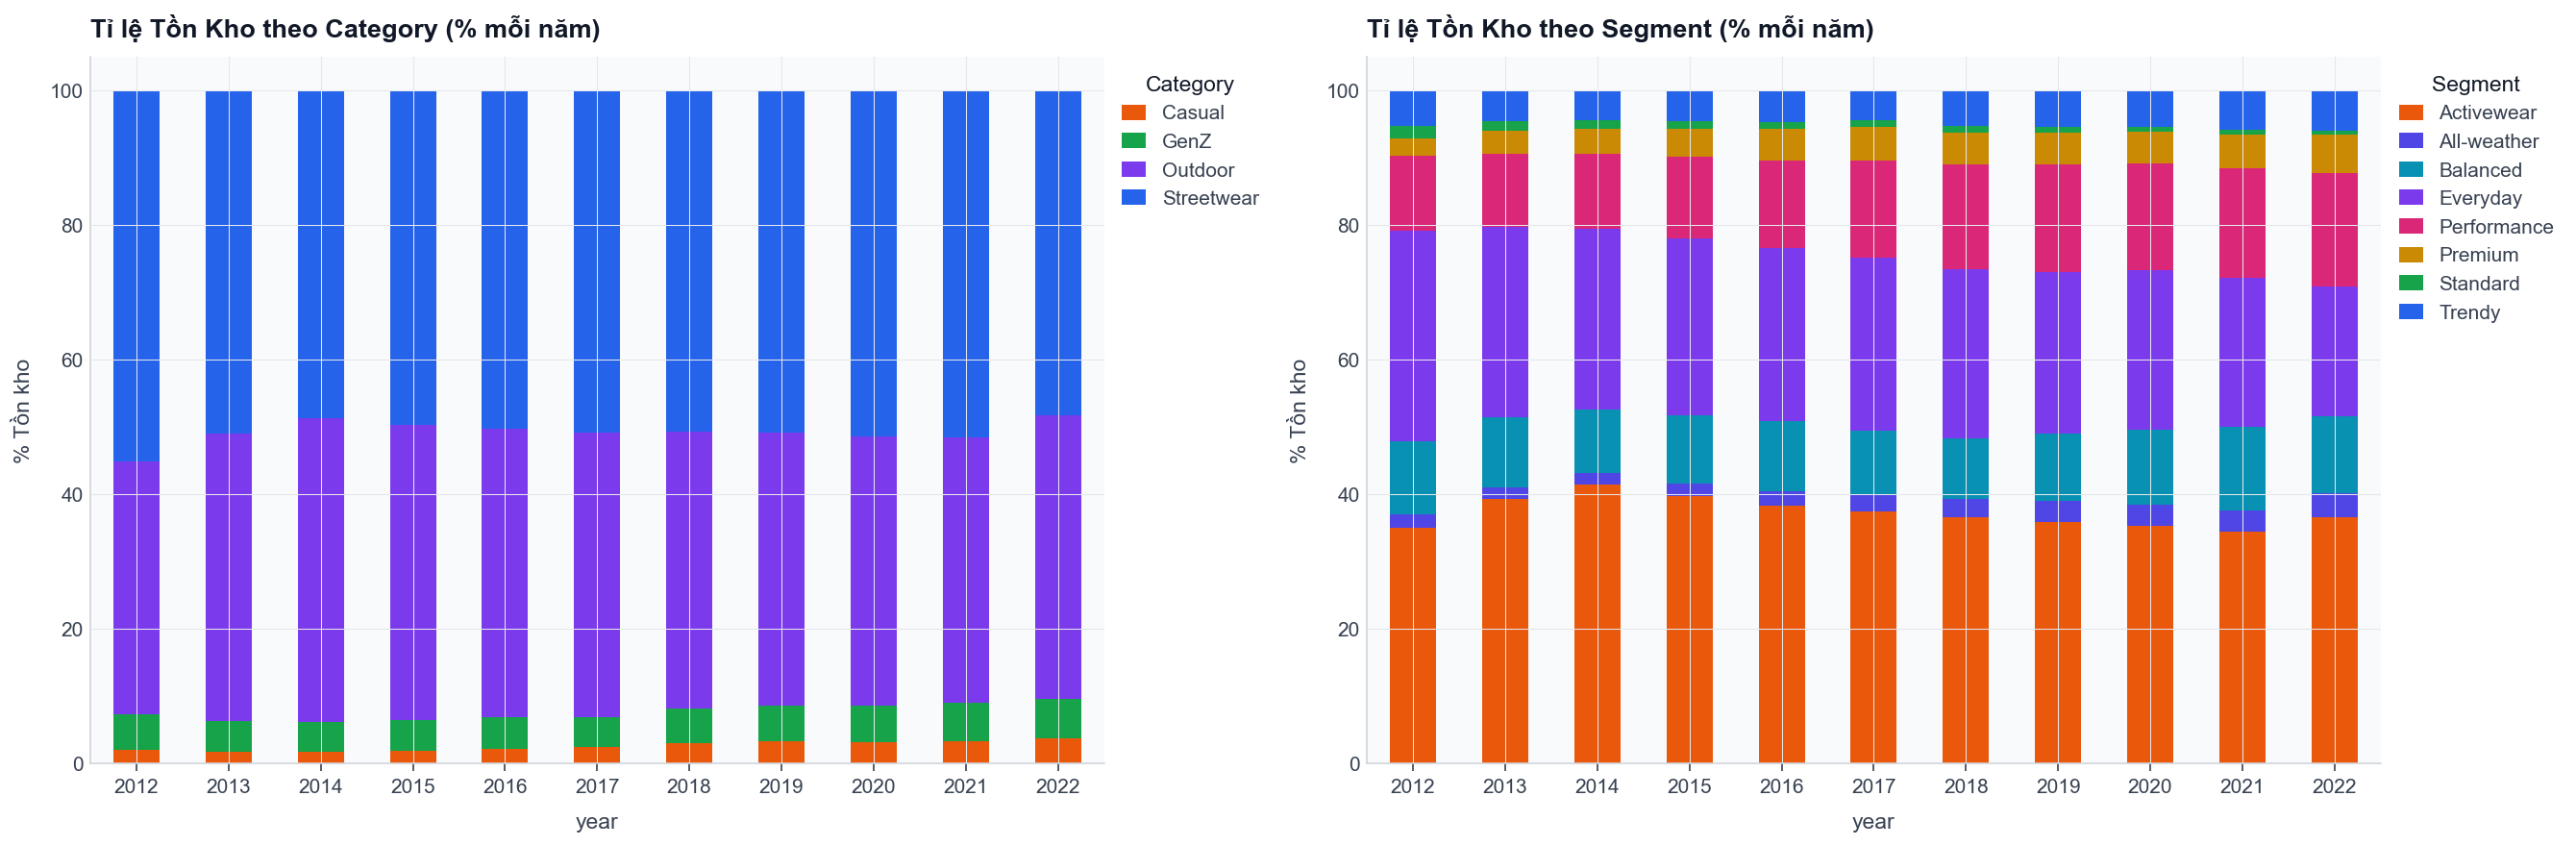

In [13]:
# ---- 4.3: Biểu đồ tỉ lệ tồn kho theo nhóm SP (category + segment) ----
print('=' * 90)
print('4.3 TỈ LỆ TỒN KHO THEO NHÓM SẢN PHẨM (Category & Segment)')
print('=' * 90)

inv_cat = inv_clean.groupby(['year', 'category']).agg(
    total_stock=('stock_on_hand', 'sum'),
    total_sold=('units_sold', 'sum'),
).reset_index()
inv_cat['sell_through'] = inv_cat['total_sold'] / (inv_cat['total_stock'] + inv_cat['total_sold']) * 100
inv_cat['pct_stock'] = inv_cat.groupby('year')['total_stock'].transform(lambda x: x / x.sum() * 100)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Stacked bar: tồn kho theo category theo năm
pivot_stock = inv_cat.pivot(index='year', columns='category', values='pct_stock')
pivot_stock.plot(kind='bar', stacked=True, ax=axes[0], color=colors_for(pivot_stock.columns.tolist(), known_map='category'), edgecolor='white')
axes[0].set_title('Tỉ lệ Tồn Kho theo Category (% mỗi năm)', fontweight='bold')
axes[0].set_ylabel('% Tồn kho')
axes[0].legend(title='Category', bbox_to_anchor=(1.0, 1.0))
axes[0].tick_params(axis='x', rotation=0)

# Segment
inv_seg = inv_clean.groupby(['year', 'segment']).agg(
    total_stock=('stock_on_hand', 'sum'),
).reset_index()
inv_seg['pct_stock'] = inv_seg.groupby('year')['total_stock'].transform(lambda x: x / x.sum() * 100)

pivot_seg = inv_seg.pivot(index='year', columns='segment', values='pct_stock')
pivot_seg.plot(kind='bar', stacked=True, ax=axes[1], color=colors_for(pivot_seg.columns.tolist(), known_map='segment'), edgecolor='white')
axes[1].set_title('Tỉ lệ Tồn Kho theo Segment (% mỗi năm)', fontweight='bold')
axes[1].set_ylabel('% Tồn kho')
axes[1].legend(title='Segment', bbox_to_anchor=(1.0, 1.0))
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


4.4 PHÂN KHÚC THEO GROSS BOOKED DEMAND — ALL ORDER_STATUS


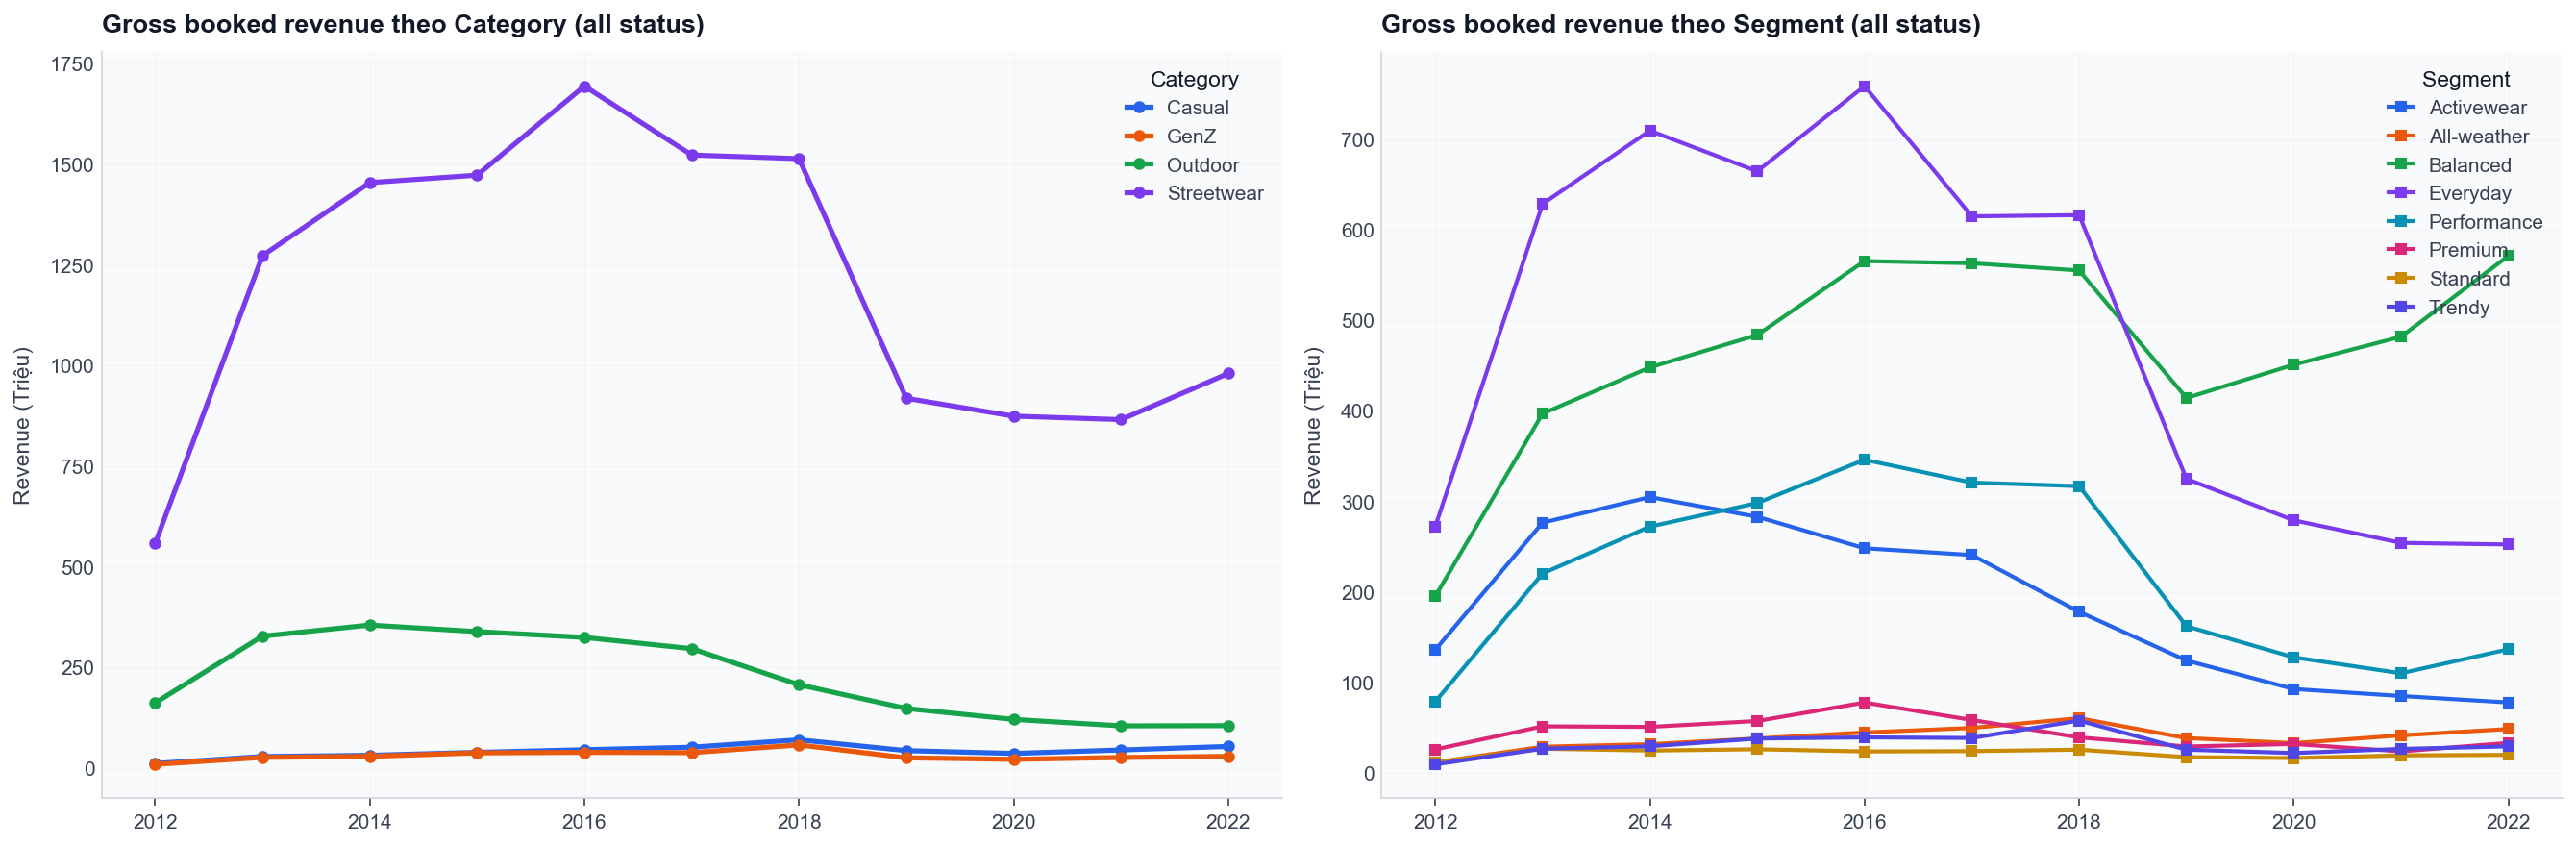

In [14]:
# ---- 4.4: Phân khúc nào tạo GROSS BOOKED DEMAND nhiều qua các NĂM ----
print('=' * 90)
print('4.4 PHÂN KHÚC THEO GROSS BOOKED DEMAND — ALL ORDER_STATUS')
print('=' * 90)

oi_prod = oi.merge(products_clean[['product_id', 'category', 'segment', 'color']], on='product_id', how='inner')
oi_prod['year'] = oi_prod['order_date'].dt.year

# Revenue theo Category + Year: gross_line all-status, align voi sales.Revenue target.
cat_year = oi_prod.groupby(['year', 'category']).agg(
    revenue=('gross_line', 'sum'),
    n_orders=('order_id', 'nunique'),
    qty=('quantity', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Line chart: Revenue theo Category
for cat in cat_year['category'].unique():
    data = cat_year[cat_year['category'] == cat]
    axes[0].plot(data['year'], data['revenue']/1e6, marker='o', label=cat, linewidth=2.5)

axes[0].set_title('Gross booked revenue theo Category (all status)', fontweight='bold')
axes[0].set_ylabel('Revenue (Triệu)')
axes[0].legend(title='Category')
axes[0].grid(alpha=0.3)

# Segment
seg_year = oi_prod.groupby(['year', 'segment']).agg(revenue=('gross_line', 'sum')).reset_index()
for seg in seg_year['segment'].unique():
    data = seg_year[seg_year['segment'] == seg]
    axes[1].plot(data['year'], data['revenue']/1e6, marker='s', label=seg, linewidth=2)

axes[1].set_title('Gross booked revenue theo Segment (all status)', fontweight='bold')
axes[1].set_ylabel('Revenue (Triệu)')
axes[1].legend(title='Segment')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


4.4b TỈ LỆ GROSS BOOKED REVENUE THEO SEGMENT — ALL ORDER_STATUS
4 năm gần nhất: [np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022)]


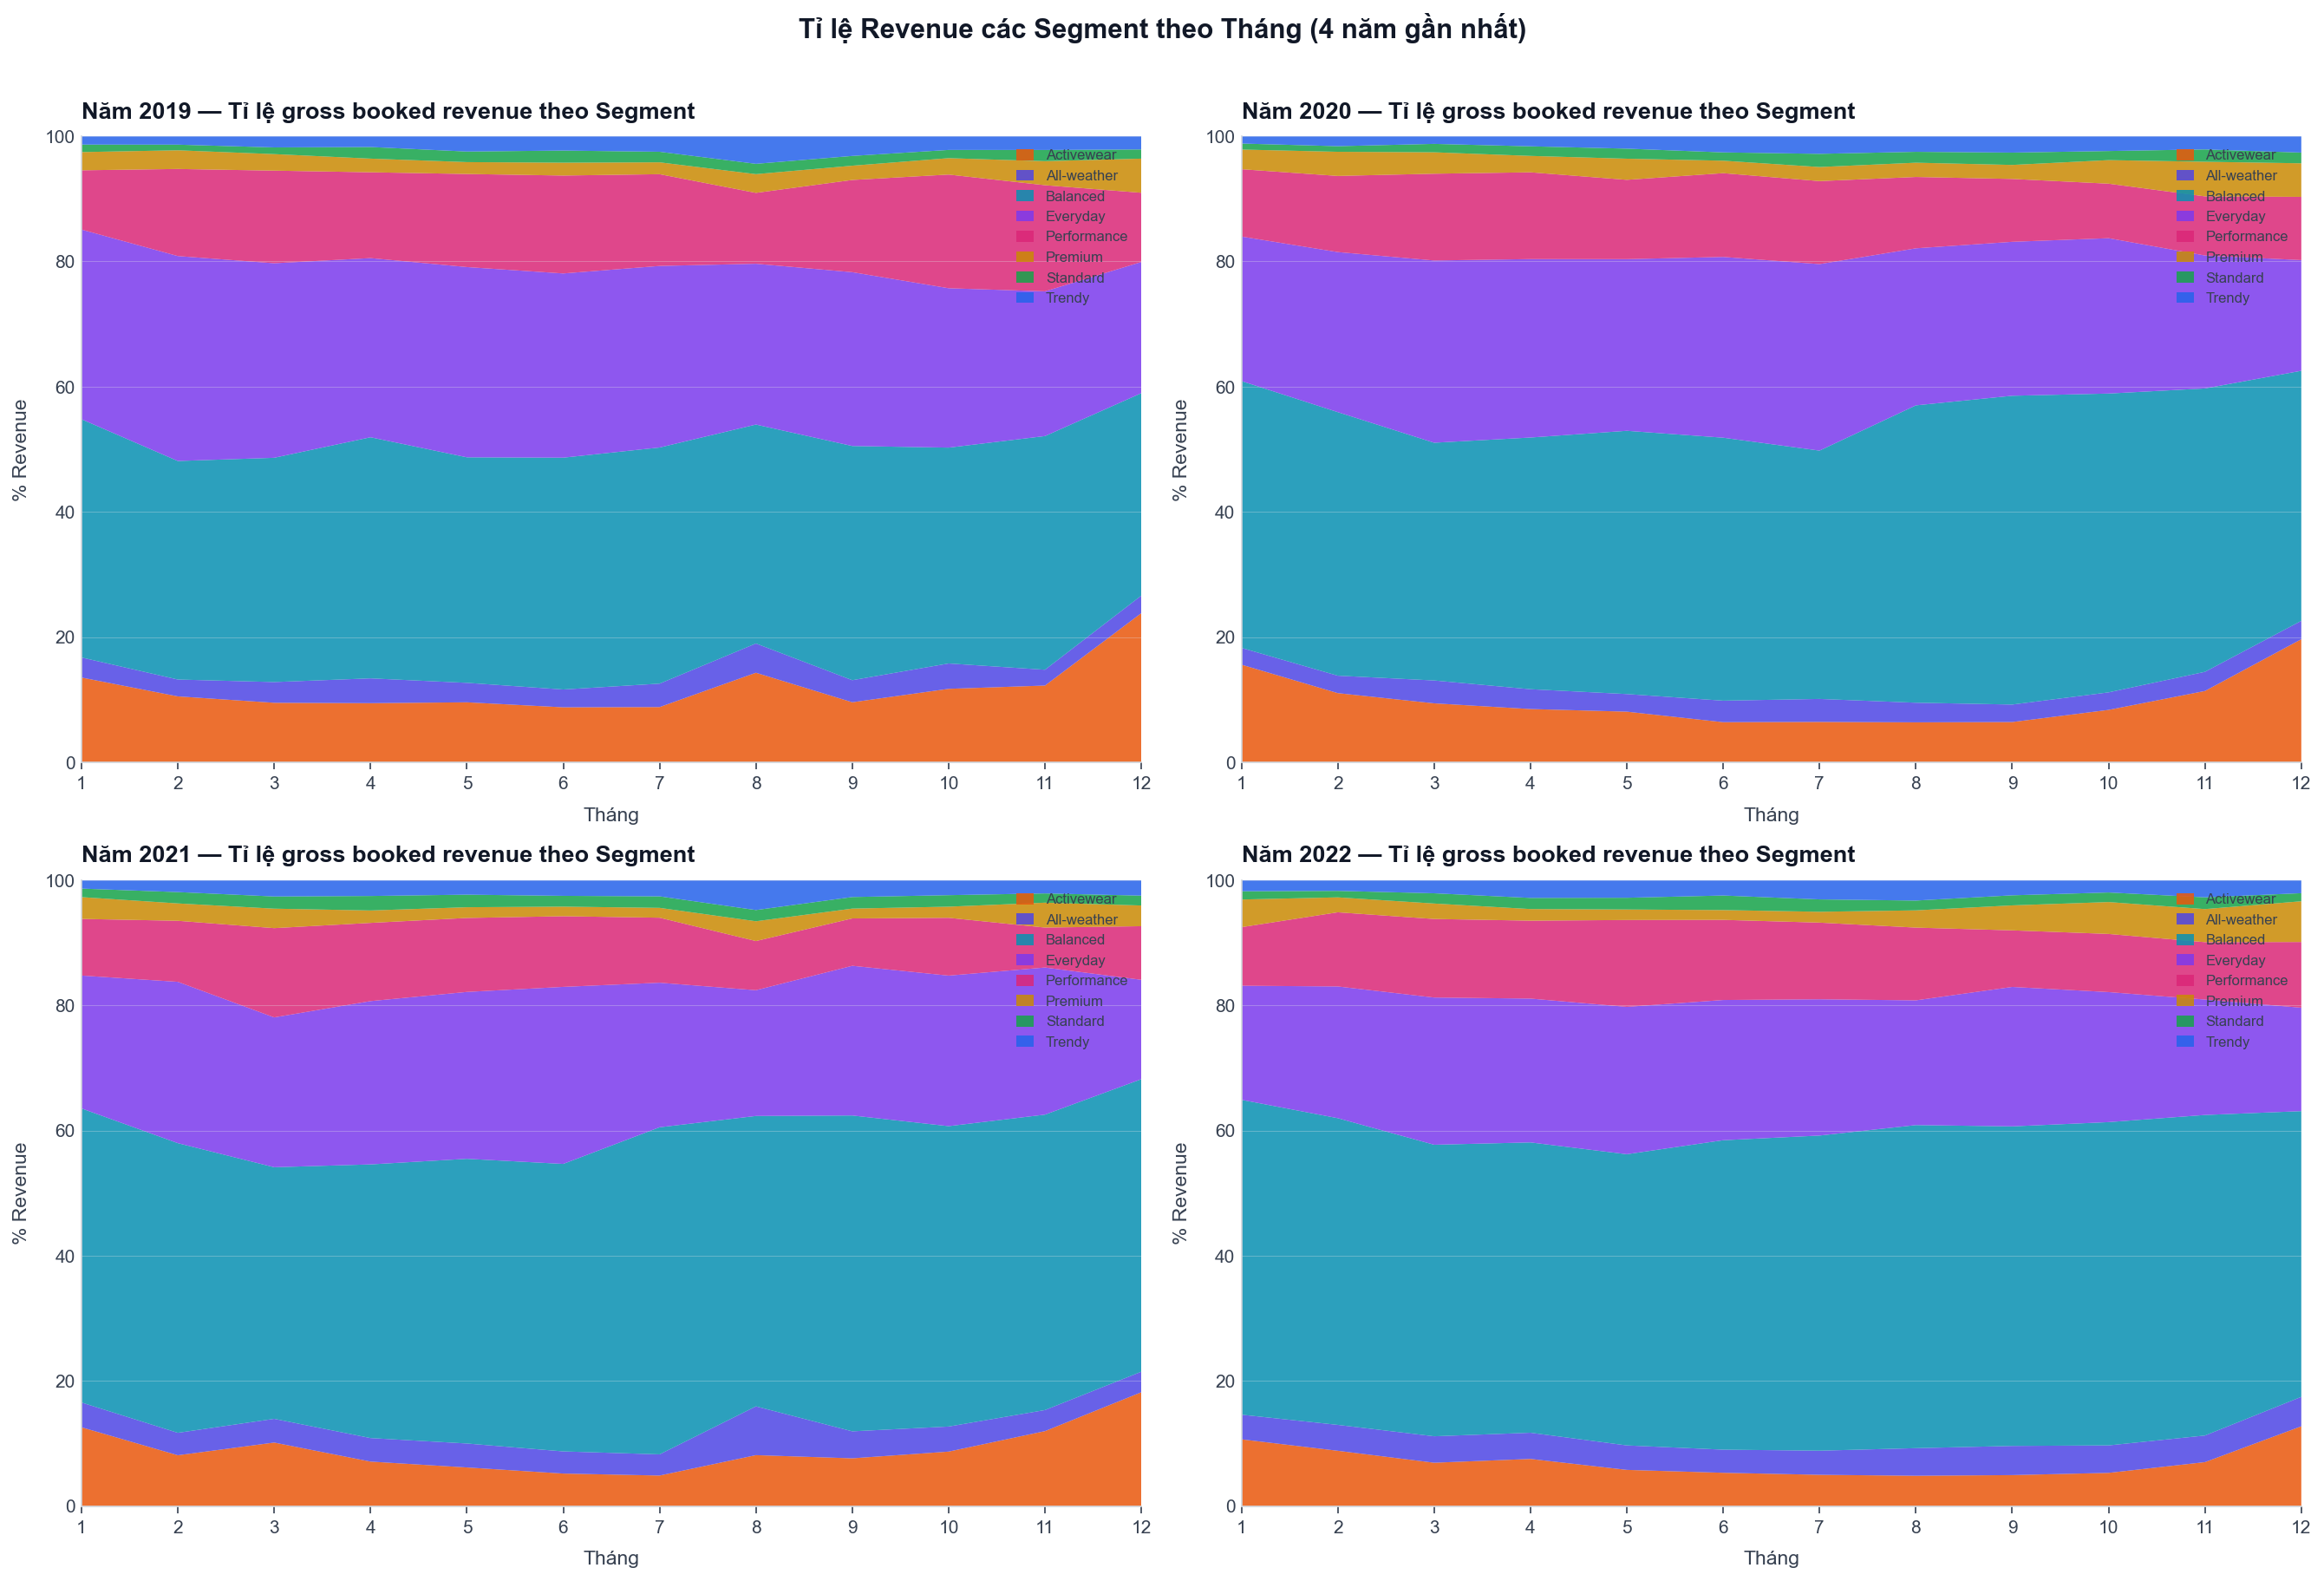


Tỉ lệ Revenue trung bình theo Segment (4 năm gần nhất):
  Balanced            :  43.8%
  Everyday            :  24.5%
  Performance         :  11.7%
  Activewear          :   9.5%
  All-weather         :   3.7%
  Premium             :   3.0%
  Trendy              :   2.3%
  Standard            :   1.6%


In [15]:
# ---- 4.4b: Tỉ lệ gross booked revenue theo Segment — TỪNG THÁNG trong 4 năm gần nhất ----
print('=' * 90)
print('4.4b TỈ LỆ GROSS BOOKED REVENUE THEO SEGMENT — ALL ORDER_STATUS')
print('=' * 90)

# Lấy 4 năm gần nhất
all_years = sorted(oi_prod['year'].unique())
last_4_years = all_years[-4:]
print(f'4 năm gần nhất: {last_4_years}')

oi_recent = oi_prod[oi_prod['year'].isin(last_4_years)].copy()
oi_recent['month'] = oi_recent['order_date'].dt.month

# Revenue theo year + month + segment
seg_month = oi_recent.groupby(['year', 'month', 'segment']).agg(
    revenue=('gross_line', 'sum')
).reset_index()

# Tính tỉ lệ % trong từng tháng
seg_month['pct'] = seg_month.groupby(['year', 'month'])['revenue'].transform(lambda x: x / x.sum() * 100)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

segments = sorted(seg_month['segment'].unique())
colors = colors_for(segments, known_map='segment')

for idx, yr in enumerate(last_4_years):
    ax = axes[idx]
    yr_data = seg_month[seg_month['year'] == yr]
    
    # Pivot: month x segment -> pct
    pivot = yr_data.pivot(index='month', columns='segment', values='pct').fillna(0)
    pivot = pivot.reindex(range(1, 13), fill_value=0)  # đảm bảo đủ 12 tháng
    
    # Stacked area chart
    ax.stackplot(pivot.index, [pivot[s].values for s in segments],
                 labels=segments, colors=colors, alpha=0.85)
    
    ax.set_title(f'Năm {yr} — Tỉ lệ gross booked revenue theo Segment', fontsize=13, fontweight='bold')
    ax.set_xlabel('Tháng')
    ax.set_ylabel('% Revenue')
    ax.set_xlim(1, 12)
    ax.set_ylim(0, 100)
    ax.set_xticks(range(1, 13))
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Tỉ lệ Revenue các Segment theo Tháng (4 năm gần nhất)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Bảng số liệu trung bình
print('\nTỉ lệ Revenue trung bình theo Segment (4 năm gần nhất):')
avg_pct = seg_month.groupby('segment')['pct'].mean().sort_values(ascending=False)
for seg, pct in avg_pct.items():
    print(f'  {seg:20s}: {pct:5.1f}%')


4.5 MÀU SẮC — GROSS BOOKED REVENUE ALL ORDER_STATUS

Top 10 màu theo gross booked revenue (toàn thời gian, all order_status):


,color,revenue,qty,n_orders
0,green,2.242130e+09,369657,81965
1,purple,2.221974e+09,427531,94639
2,silver,2.002091e+09,316862,70544
3,yellow,1.786231e+09,331528,73543
4,white,1.624511e+09,358371,79542
5,black,1.538528e+09,301748,67030
6,blue,1.309219e+09,282407,63090
7,red,1.258412e+09,261421,58082
8,orange,1.252300e+09,334917,74272
9,pink,1.195082e+09,228701,50842


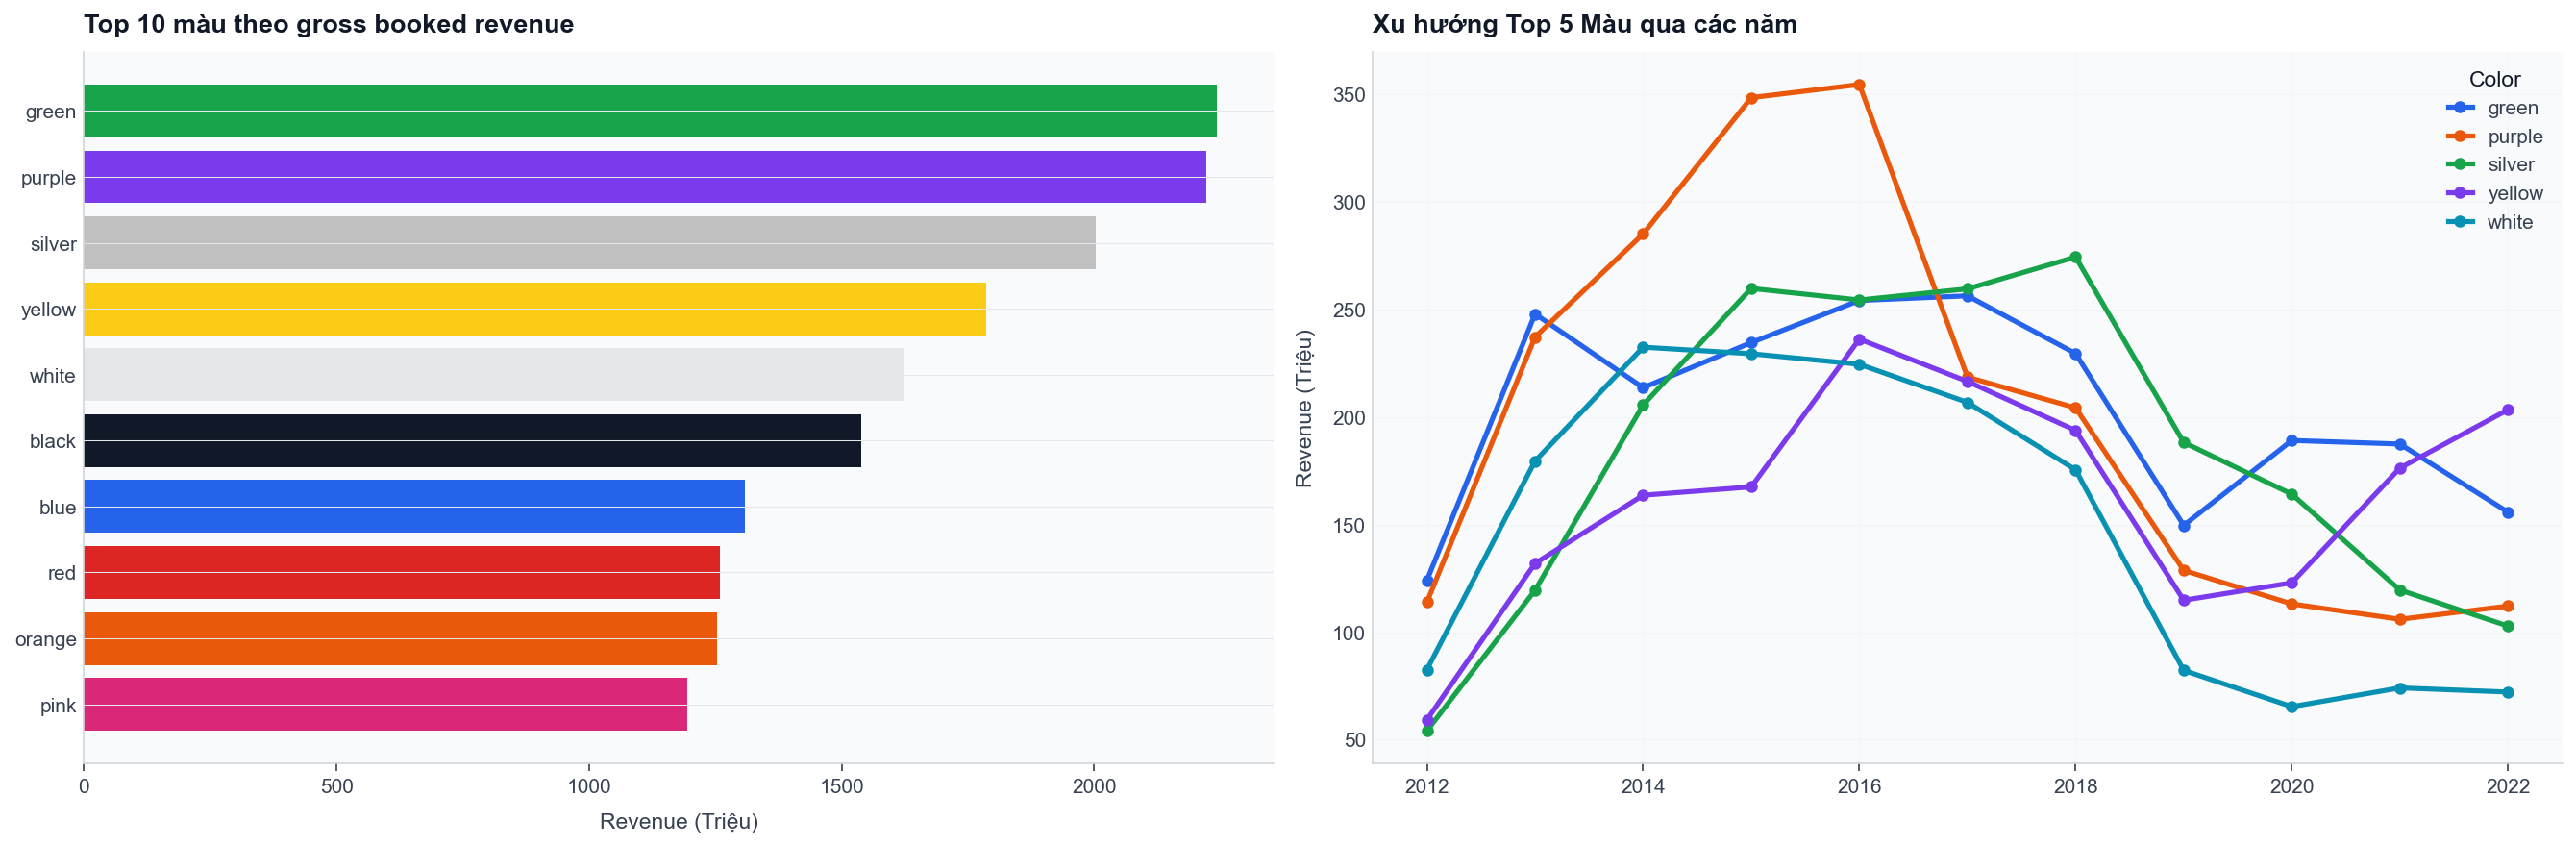


✅ TỔNG KẾT PHẦN 4:
  - Category thống trị: Streetwear (chiếm phần lớn Revenue mọi năm)
  - Màu đóng góp gross booked revenue cao nhất: green (Rev: 2,242M)
  - SP biến động cao có nguy cơ đứt hàng cần buffer stock / reorder sớm hơn


In [16]:
# ---- 4.5: MÀU SẮC — Màu nào đóng góp gross booked revenue nhiều nhất (all-status) ----
print('=' * 90)
print('4.5 MÀU SẮC — GROSS BOOKED REVENUE ALL ORDER_STATUS')
print('=' * 90)

# Toàn thời gian
color_total = oi_prod.groupby('color').agg(
    revenue=('gross_line', 'sum'),
    qty=('quantity', 'sum'),
    n_orders=('order_id', 'nunique')
).sort_values('revenue', ascending=False).reset_index()

print('\nTop 10 màu theo gross booked revenue (toàn thời gian, all order_status):')
display(color_total.head(10))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart top 10
top10_colors = color_total.head(10)
product_color_map = {
    'green': '#16A34A', 'purple': '#7C3AED', 'silver': '#C0C0C0',
    'yellow': '#FACC15', 'white': '#E5E7EB', 'black': '#111827',
    'blue': '#2563EB', 'red': '#DC2626', 'orange': '#EA580C', 'pink': '#DB2777',
}
bar_colors = top10_colors['color'].map(product_color_map).fillna(CLR_MUTED)
axes[0].barh(top10_colors['color'][::-1], top10_colors['revenue'][::-1]/1e6, color=bar_colors[::-1], edgecolor='#CBD5E1')
axes[0].set_title('Top 10 màu theo gross booked revenue', fontweight='bold')
axes[0].set_xlabel('Revenue (Triệu)')

# Theo năm: top 5 màu, line chart
top5_colors = color_total.head(5)['color'].tolist()
color_year = oi_prod[oi_prod['color'].isin(top5_colors)].groupby(['year', 'color']).agg(
    revenue=('gross_line', 'sum')
).reset_index()

for c in top5_colors:
    data = color_year[color_year['color'] == c]
    axes[1].plot(data['year'], data['revenue']/1e6, marker='o', linewidth=2.5, label=c)

axes[1].set_title('Xu hướng Top 5 Màu qua các năm', fontweight='bold')
axes[1].set_ylabel('Revenue (Triệu)')
axes[1].legend(title='Color')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\n✅ TỔNG KẾT PHẦN 4:')
print(f'  - Category thống trị: Streetwear (chiếm phần lớn Revenue mọi năm)')
print(f'  - Màu đóng góp gross booked revenue cao nhất: {color_total.iloc[0]["color"]} (Rev: {color_total.iloc[0]["revenue"]/1e6:,.0f}M)')
print(f'  - SP biến động cao có nguy cơ đứt hàng cần buffer stock / reorder sớm hơn')
